## - Student: LINETH GUERRA
## - Tuition: A01795639

# Introduction to financial technical analysis

# 📌 Objectives

By the end of this notebook, students will be able to:

1. **Access and Manipulate Financial Data:**
   - Use the `yfinance` library to retrieve historical stock prices for all companies in the S&P 500 index.

2. **Compute Key Technical Indicators:**
   - Calculate 50-day and 200-day moving averages for each stock in the index.

3. **Detect Trading Signals:**
   - Identify Golden Crosses and Death Crosses as described in technical analysis literature.

4. **Analyze Recent Market Behavior:**
   - Isolate and examine stocks that experienced technical signals (crosses) in the last 14 days.

5. **Visualize Price Trends and Volatility:**
   - Plot historical price movements along with moving averages, and compute volatility around signal dates.

6. **Interpret Technical Indicators in Context:**
   - Reflect on what Golden and Death Crosses signify and how traders may respond to them.

7. **Evaluate Strategy Viability:**
   - Discuss the strengths and limitations of using moving averages as a standalone trading strategy.

8. **Connect Technical Analysis to Broader Market Intelligence:**
   - Explore how sentiment analysis and news (covered in later sections) could complement technical signals.

9. **Develop Critical Thinking About Signal Reliability:**
   - Assess potential risks of false positives and propose improvements or filters to enhance signal accuracy.

10. **Engage in Strategic Reflection:**
    - Answer analytical questions aimed at understanding the utility, risks, and presentation of the strategy to a professional audience.


## Import and install librairies

In [1]:
#%pip install pandas
#%pip install yfinance
#%pip install lxml
#%pip install matplotlib

In [2]:
import yfinance as yf
import pandas as pd
import requests
from bs4 import BeautifulSoup
import re
import matplotlib.pyplot as plt
import numpy as np
import time

import warnings
warnings.filterwarnings(
    "ignore",
    message="YF.download\\(\\) has changed argument auto_adjust default to True",
    category=FutureWarning
)

## Get the list of stocks in the S&P 500

In [3]:
# Read and print the stock tickers that make up S&P500
df_tickers = pd.read_html(
    'https://en.wikipedia.org/wiki/List_of_S%26P_500_companies')[0]
print(df_tickers.head())

  Symbol             Security             GICS Sector  \
0    MMM                   3M             Industrials   
1    AOS          A. O. Smith             Industrials   
2    ABT  Abbott Laboratories             Health Care   
3   ABBV               AbbVie             Health Care   
4    ACN            Accenture  Information Technology   

                GICS Sub-Industry    Headquarters Location  Date added  \
0        Industrial Conglomerates    Saint Paul, Minnesota  1957-03-04   
1               Building Products     Milwaukee, Wisconsin  2017-07-26   
2           Health Care Equipment  North Chicago, Illinois  1957-03-04   
3                   Biotechnology  North Chicago, Illinois  2012-12-31   
4  IT Consulting & Other Services          Dublin, Ireland  2011-07-06   

       CIK      Founded  
0    66740         1902  
1    91142         1916  
2     1800         1888  
3  1551152  2013 (1888)  
4  1467373         1989  


In [4]:
display(df_tickers)

,Symbol,Security,GICS Sector,GICS Sub-Industry,Headquarters Location,Date added,CIK,Founded
0,MMM,3M,Industrials,Industrial Conglomerates,"Saint Paul, Minnesota",1957-03-04,66740,1902
1,AOS,A. O. Smith,Industrials,Building Products,"Milwaukee, Wisconsin",2017-07-26,91142,1916
2,ABT,Abbott Laboratories,Health Care,Health Care Equipment,"North Chicago, Illinois",1957-03-04,1800,1888
3,ABBV,AbbVie,Health Care,Biotechnology,"North Chicago, Illinois",2012-12-31,1551152,2013 (1888)
4,ACN,Accenture,Information Technology,IT Consulting & Other Services,"Dublin, Ireland",2011-07-06,1467373,1989
...,...,...,...,...,...,...,...,...
498,XYL,Xylem Inc.,Industrials,Industrial Machinery & Supplies & Components,"White Plains, New York",2011-11-01,1524472,2011
499,YUM,Yum! Brands,Consumer Discretionary,Restaurants,"Louisville, Kentucky",1997-10-06,1041061,1997
500,ZBRA,Zebra Technologies,Information Technology,Electronic Equipment & Instruments,"Lincolnshire, Illinois",2019-12-23,877212,1969
501,ZBH,Zimmer Biomet,Health Care,Health Care Equipment,"Warsaw, Indiana",2001-08-07,1136869,1927


In [5]:
ticker_list = df_tickers['Symbol'].str.strip().str.replace('.', '-', regex=False).tolist()
len(ticker_list)

503

## Get the closing price of all 500 stocks in the S&P 500 Index
Use the yfinance library to retrieve the close price of all 500 stocks in the index between 2024-05-01 and 2025-05-01
https://ranaroussi.github.io/yfinance/reference/yfinance.stock.html

In [6]:
start_date = '2024-05-01'
end_date = '2025-05-01'

In [7]:
# CODE HERE
# Use as many coding cells as you need

# Load closing prices
# Make sure you end this coding section by displaying your results: display(df_close)

#Clean the ticker list (replace '.' with '-' for compatibility)
ticker_list = df_tickers['Symbol'].str.replace('.', '-', regex=False).tolist()

# Download data (closing prices only)
df_close = yf.download(ticker_list, start=start_date, end=end_date, auto_adjust=True)['Close']

#Display results
display(df_close)

[*********************100%***********************]  503 of 503 completed


Ticker,A,AAPL,ABBV,ABNB,ABT,ACGL,ACN,ADBE,ADI,ADM,...,WY,WYNN,XEL,XOM,XYL,XYZ,YUM,ZBH,ZBRA,ZTS
Date,,,,,,,,,,,,,,,,,,,,,
2024-05-01,137.376282,168.283661,154.714767,156.160004,103.735443,91.096085,293.442139,469.390015,189.859940,55.668907,...,29.172791,91.453217,51.484386,111.217094,129.094391,66.839996,132.078354,118.202538,309.049988,156.223297
2024-05-02,136.217361,171.991287,153.844193,158.330002,103.374352,90.497009,295.092743,476.570007,192.405899,56.603554,...,29.955240,93.958229,51.493965,111.418365,134.052750,70.300003,131.824615,117.115044,312.709991,164.827896
2024-05-03,138.129074,182.279160,156.695099,159.710007,103.354828,89.774330,298.403900,486.179993,195.480637,56.431889,...,30.032516,95.378410,51.934326,111.188332,135.255371,69.470001,131.112137,120.278709,309.589996,164.670197
2024-05-06,139.278076,180.619186,155.681030,162.000000,103.101067,92.370285,300.712830,493.589996,199.093948,57.404686,...,30.022860,96.522438,52.039631,111.907227,137.217010,73.529999,132.907913,119.191200,315.790009,163.566269
2024-05-07,139.931839,181.305023,155.508820,159.809998,103.618332,93.387741,305.232422,492.269989,199.338730,58.739902,...,29.800682,95.891258,52.671455,111.351273,138.035187,71.599998,132.644424,120.051323,317.869995,166.030365
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2025-04-24,106.795090,208.097107,178.825470,121.709999,128.801849,92.099998,291.410004,360.910004,194.345154,48.284031,...,25.294355,81.371361,69.709930,107.638626,115.241966,57.500000,146.859604,101.237473,244.080002,151.792435
2025-04-25,106.056648,209.005920,184.466751,122.510002,128.274216,90.680000,293.390015,367.720001,193.708054,47.759418,...,24.609919,81.900002,68.430580,107.579178,115.730400,58.090000,146.580978,101.247452,246.240005,152.958542
2025-04-28,106.645409,209.864792,190.692963,123.300003,128.951172,91.190002,293.250000,368.619995,192.841995,47.561451,...,25.363791,81.989769,69.005791,107.638626,115.550972,58.320000,147.028778,101.496803,243.490005,153.058212


## Identify Golden and Death Crosses

### Get Moving Averages 50 days and 200 days

In [8]:
# CODE HERE
# Use as many coding cells as you need

# Compute moving averages
# Make sure you end this coding section by displaying your results: display(df_ma50), display(df_ma200)

# Calculate 50-day moving average
df_ma50 = df_close.rolling(window=50).mean()

# Calculate 200-day moving average
df_ma200 = df_close.rolling(window=200).mean()

# Display the moving averages and clean NaN
display(df_ma50)
display(df_ma200)

Ticker,A,AAPL,ABBV,ABNB,ABT,ACGL,ACN,ADBE,ADI,ADM,...,WY,WYNN,XEL,XOM,XYL,XYZ,YUM,ZBH,ZBRA,ZTS
Date,,,,,,,,,,,,,,,,,,,,,
2024-05-01,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2024-05-02,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2024-05-03,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2024-05-06,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2024-05-07,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2025-04-24,118.589774,219.229514,194.882049,128.497001,129.695851,91.7206,322.755805,401.392800,204.386194,46.354729,...,28.290147,82.616266,68.725403,109.007224,120.092335,60.865000,151.386326,105.303733,277.851799,158.931158
2025-04-25,117.960953,218.678437,194.779480,128.136801,129.675177,91.7690,320.885378,399.492000,204.194041,46.424616,...,28.199398,82.695181,68.768236,109.031401,119.825021,60.367001,151.415763,105.358225,275.718199,158.535975
2025-04-28,117.376369,218.051459,194.792595,127.782001,129.642278,91.7896,318.998219,397.680000,203.901112,46.480951,...,28.121558,82.734114,68.802902,109.041310,119.530667,59.847600,151.409784,105.399390,274.119598,158.320589


Ticker,A,AAPL,ABBV,ABNB,ABT,ACGL,ACN,ADBE,ADI,ADM,...,WY,WYNN,XEL,XOM,XYL,XYZ,YUM,ZBH,ZBRA,ZTS
Date,,,,,,,,,,,,,,,,,,,,,
2024-05-01,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2024-05-02,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2024-05-03,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2024-05-06,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2024-05-07,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2025-04-24,133.080366,227.101211,183.261853,130.701575,116.973859,96.197872,340.475852,478.509449,214.891999,52.358255,...,29.730782,85.165791,64.041626,111.437774,125.549300,72.28710,136.723923,106.728763,346.199799,172.881444
2025-04-25,132.988337,227.008163,183.380334,130.551875,117.119244,96.185332,340.478539,477.517949,214.720083,52.293548,...,29.719768,85.156247,64.130069,111.439660,125.467794,72.25500,136.835707,106.711043,345.854800,172.787551
2025-04-28,132.891064,226.898010,183.529515,130.409175,117.261134,96.177719,340.493397,476.538299,214.512770,52.222563,...,29.712475,85.151355,64.220807,111.437109,125.371802,72.22490,136.937422,106.688921,345.453200,172.697852


### Detecting Golden and Death Crosses in the last 14 days

In [9]:
# CODE HERE
# Use as many coding cells as you need

def detect_crosses(df_ma50, df_ma200, window=14):
    """
    Detect Golden and Death Crosses in the last `window` days
    based on the given moving averages.

    Returns two lists:
    - golden_crosses: [(ticker, date), ...]
    - death_crosses: [(ticker, date), ...]
    """
    golden_crosses = []
    death_crosses = []

    # Ensure the indices are dates
    for ticker in df_ma50.columns:
        sma50 = df_ma50[ticker]
        sma200 = df_ma200[ticker]

        signal = (sma50 > sma200).astype(int)
        cross = signal.diff()

        recent_cross = cross.tail(window)

        for date, val in recent_cross.items():
            if val == 1:
                golden_crosses.append((ticker, date.date()))
            elif val == -1:
                death_crosses.append((ticker, date.date()))

    return golden_crosses, death_crosses

# Example usage (assuming df_ma50 and df_ma200 are already calculated)
golden_crosses, death_crosses = detect_crosses(df_ma50, df_ma200, window=14)

df_golden_cross_14d = pd.DataFrame(golden_crosses, columns=['Ticker', 'Date'])
df_death_cross_14d = pd.DataFrame(death_crosses, columns=['Ticker', 'Date'])

In [10]:
# use the display function to show as many intermediary results
# for example display(df_golden_cross_14d)

print(f"Golden Crosses in the last 14 days: {len(df_golden_cross_14d)}")
display(df_golden_cross_14d)

Golden Crosses in the last 14 days: 10


,Ticker,Date
0,AMT,2025-04-21
1,CI,2025-04-30
2,EW,2025-04-17
3,INVH,2025-04-30
4,KDP,2025-04-21
5,MDLZ,2025-04-28
6,MOH,2025-04-28
7,NEM,2025-04-14
8,SBAC,2025-04-29
9,SJM,2025-04-25


In [11]:
# use the display function to show as many intermediary results
# for example display(df_death_cross_14d)
print(f"Death Crosses in the last 14 days: {len(df_death_cross_14d)}")
display(df_death_cross_14d)

Death Crosses in the last 14 days: 62


,Ticker,Date
0,ACN,2025-04-10
1,ADSK,2025-04-11
2,AME,2025-04-22
3,AMP,2025-04-24
4,AMZN,2025-04-22
...,...,...
57,UNP,2025-04-16
58,VST,2025-04-30
59,WAB,2025-04-21
60,WAT,2025-04-28


#### Golden crosses
List the first top companies in alphabetical order (by there symbol or ticker) that had a golden cross in the last 14 days:

In [12]:
# Sort Golden Crosses alphabetically by ticker symbol
df_golden_sorted = df_golden_cross_14d.sort_values(by='Ticker')

# Display only the first few results
display(df_golden_sorted.head())

,Ticker,Date
0,AMT,2025-04-21
1,CI,2025-04-30
2,EW,2025-04-17
3,INVH,2025-04-30
4,KDP,2025-04-21


#### Death crosses
List the first 10 companies in alphabetical order (by there symbol or ticker) that had a death cross in the last 14 days:

In [13]:
# Drop duplicate tickers, keep the first (most recent Death Cross per ticker)
df_death_unique = df_death_cross_14d.sort_values(by='Ticker').drop_duplicates(subset='Ticker')

# Display the first 10 alphabetically
display(df_death_unique.head(10))

,Ticker,Date
0,ACN,2025-04-10
1,ADSK,2025-04-11
2,AME,2025-04-22
3,AMP,2025-04-24
4,AMZN,2025-04-22
5,APD,2025-04-21
6,APO,2025-04-17
7,AXP,2025-04-22
8,BAC,2025-04-16
9,BLK,2025-04-16


### Visualization of the results
(in alphabetical order)

#### Compute the volatility of every stock and print it in the title of each plot

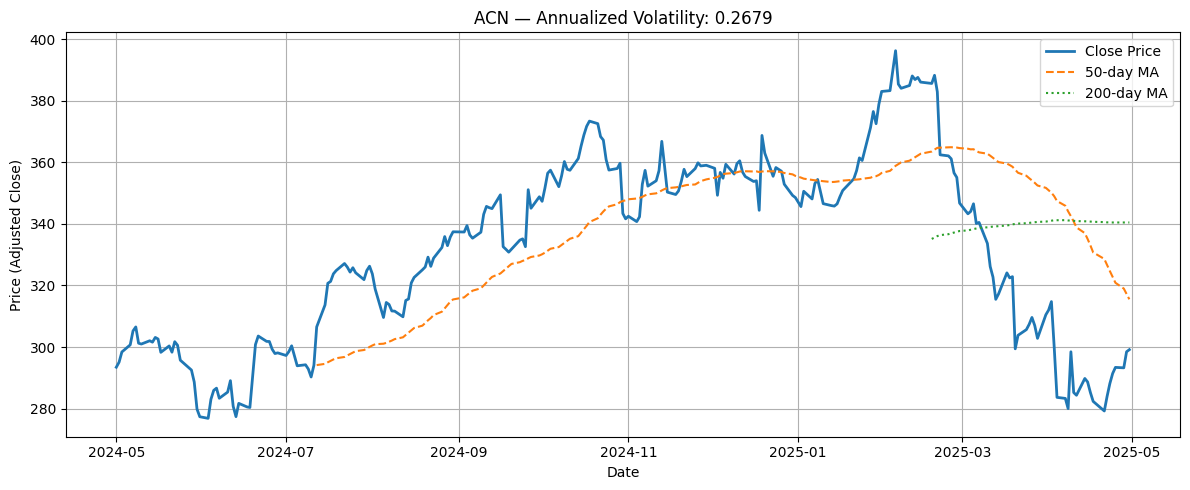

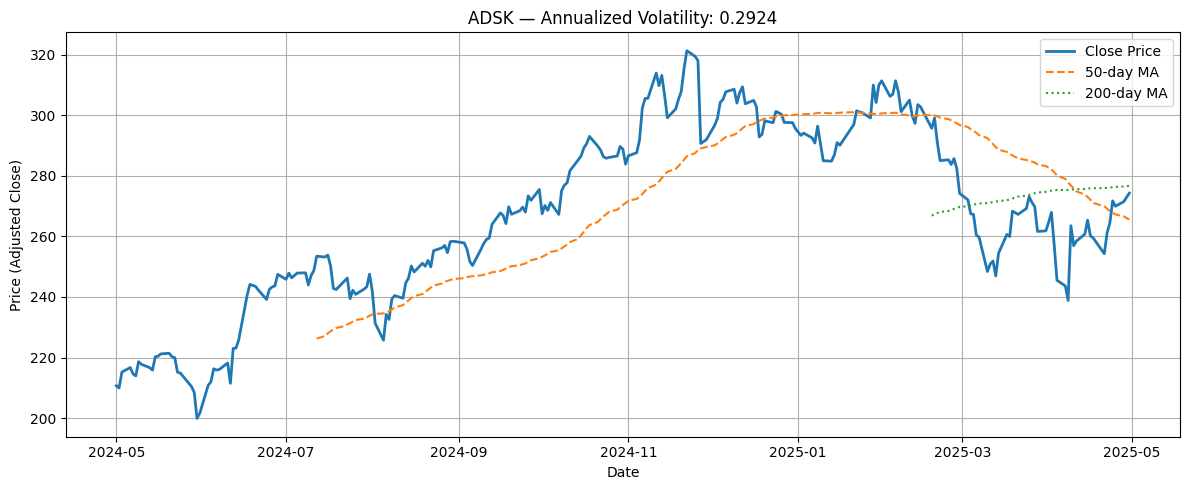

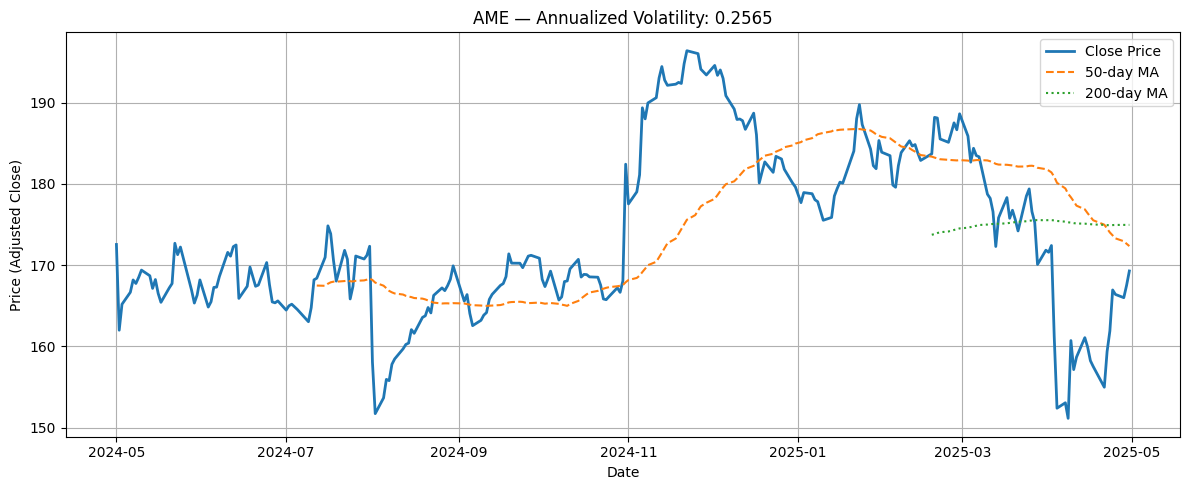

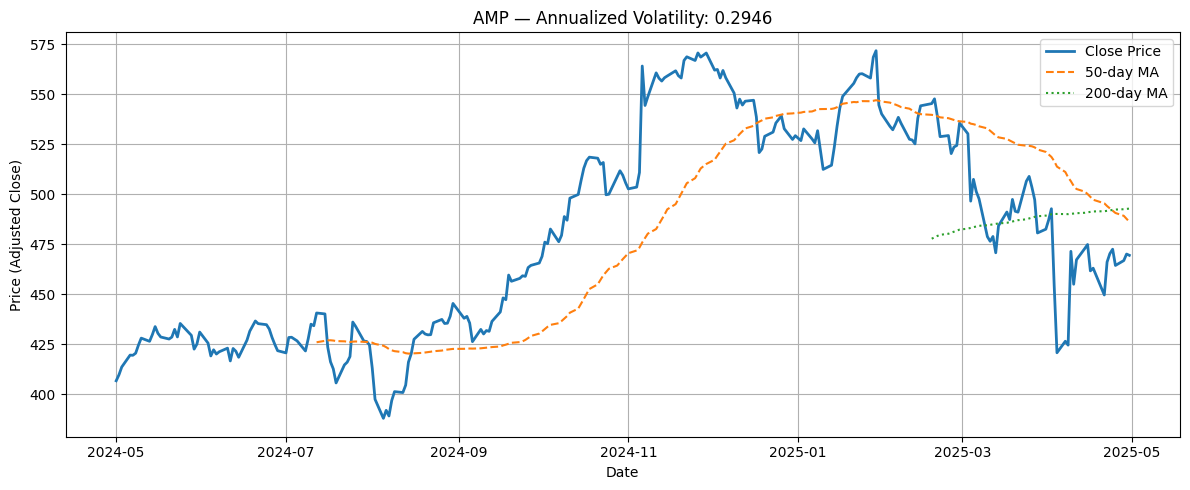

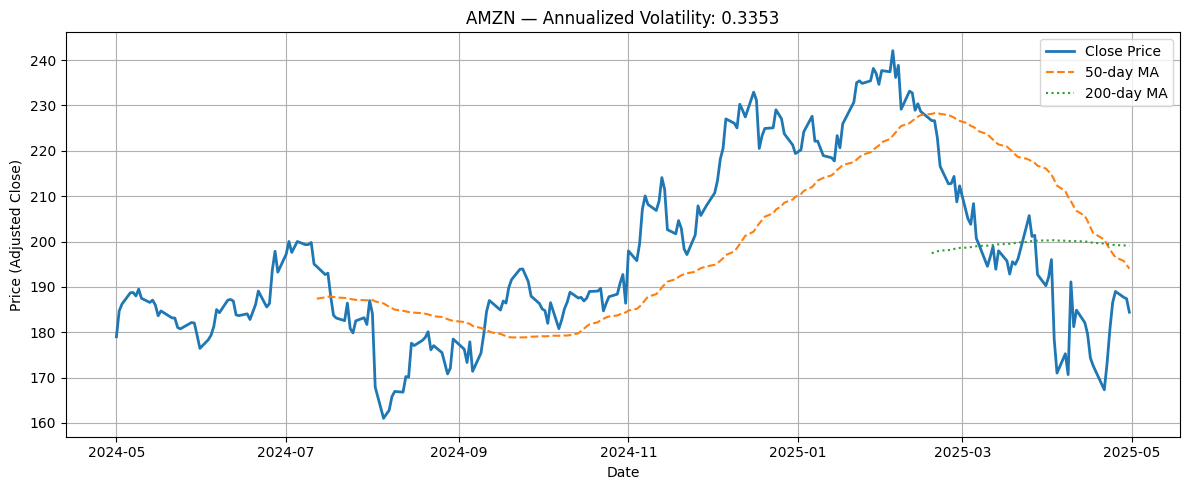

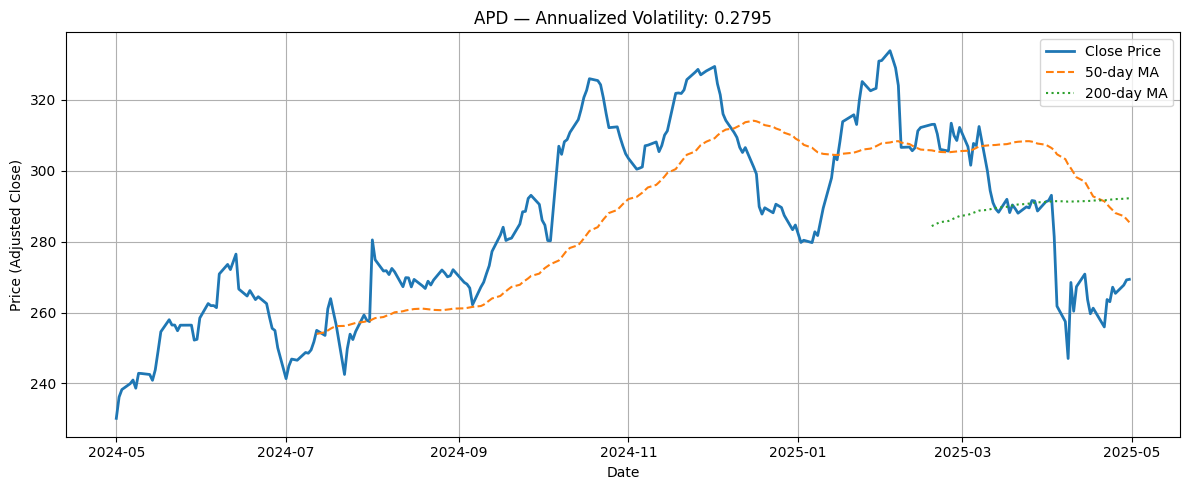

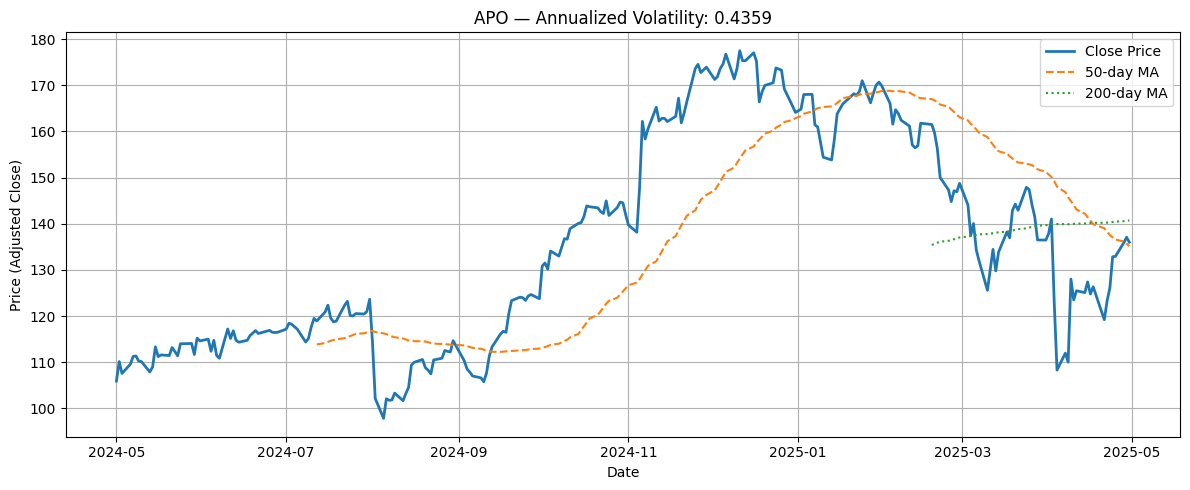

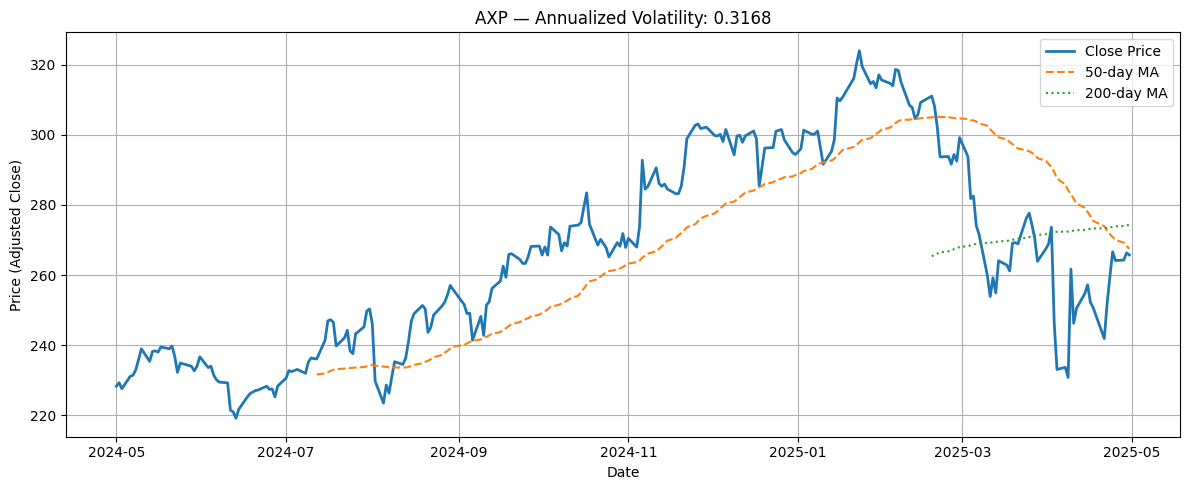

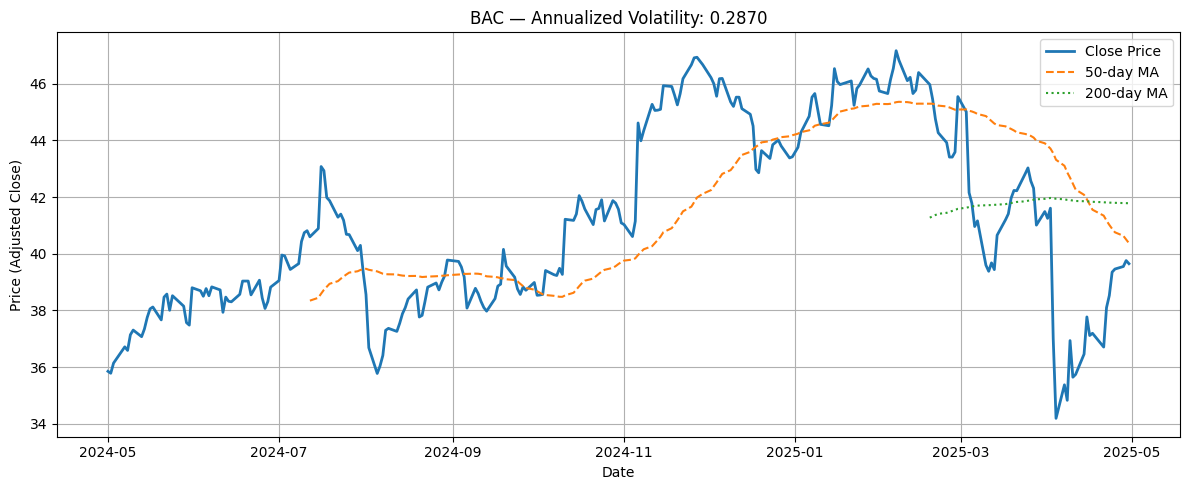

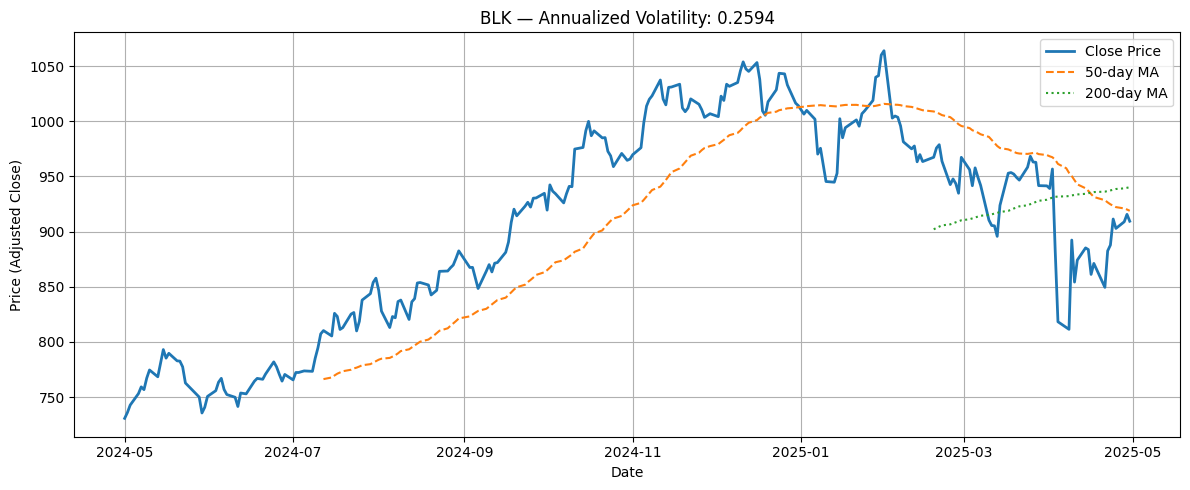

In [14]:
# Compute the volatility of every stock in the S&P 500
def compute_volatility(df_close):
    """
    Compute annualized volatility for every stock in df_close.

    Parameters:
    - df_close: DataFrame with closing prices, columns are tickers, index is datetime.

    Returns:
    - Series with volatility values indexed by ticker.
    """
    # Calculate daily returns for all stocks
    daily_returns = df_close.pct_change().dropna(how='all')

    # Calculate volatility as std dev of daily returns (annualized)
    volatility = daily_returns.std() * (252 ** 0.5)

    return volatility

# Compute volatility for all stocks
volatility = compute_volatility(df_close)

# Get the first 10 tickers with death crosses, sorted alphabetically
death_tickers = sorted(df_death_unique['Ticker'].tolist())[:10]

# Plot closing price, 50-day MA, 200-day MA, and show volatility in the title
for ticker in death_tickers:
    plt.figure(figsize=(12, 5))

    # Plot closing price
    plt.plot(df_close.index, df_close[ticker], label='Close Price', linewidth=2)

    # Plot 50-day and 200-day moving averages
    plt.plot(df_ma50.index, df_ma50[ticker], label='50-day MA', linestyle='--')
    plt.plot(df_ma200.index, df_ma200[ticker], label='200-day MA', linestyle=':')

    # Get volatility for ticker, if missing show NaN
    vol_value = volatility.get(ticker, float('nan'))

    # Title including ticker and volatility
    plt.title(f"{ticker} — Annualized Volatility: {vol_value:.4f}")

    plt.xlabel("Date")
    plt.ylabel("Price (Adjusted Close)")
    plt.legend()
    plt.grid(True)
    plt.tight_layout()
    plt.show()

#### Plot top 10 stocks that had Golden Crosses in the last 14 days

- You should have 10 plots (use a for loop) for every stock in the top 10 (in alphabetical order)
- For each plot, put the volatility of the stock in the title of the plot

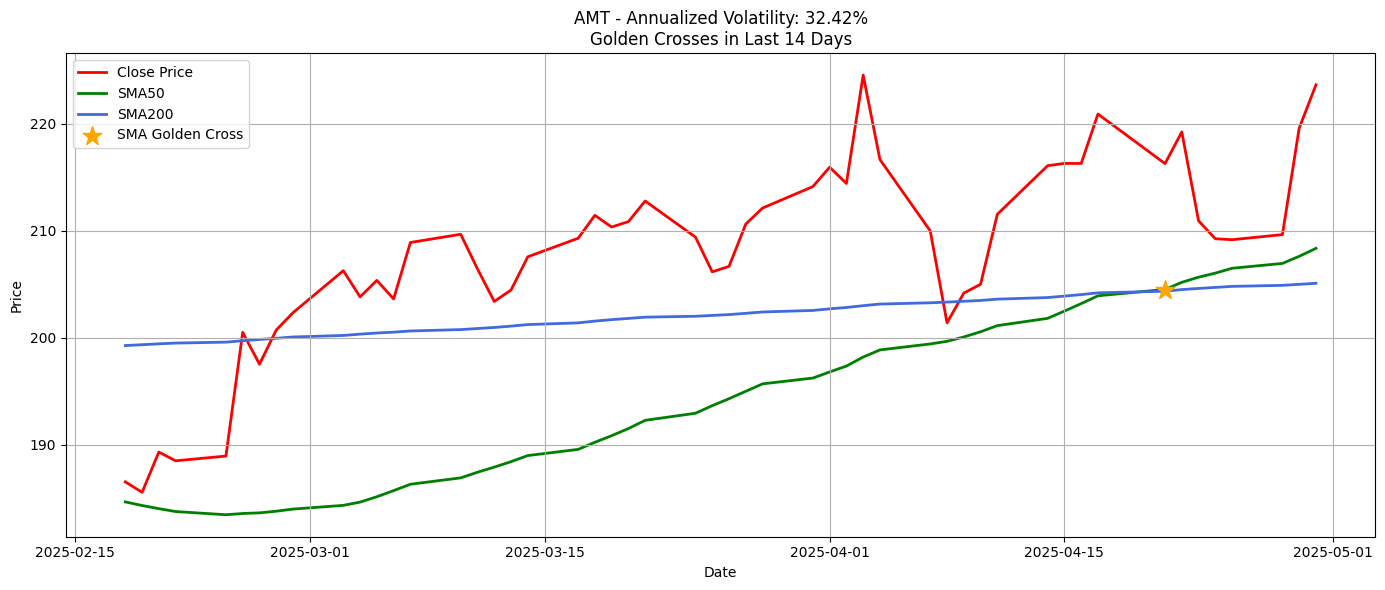

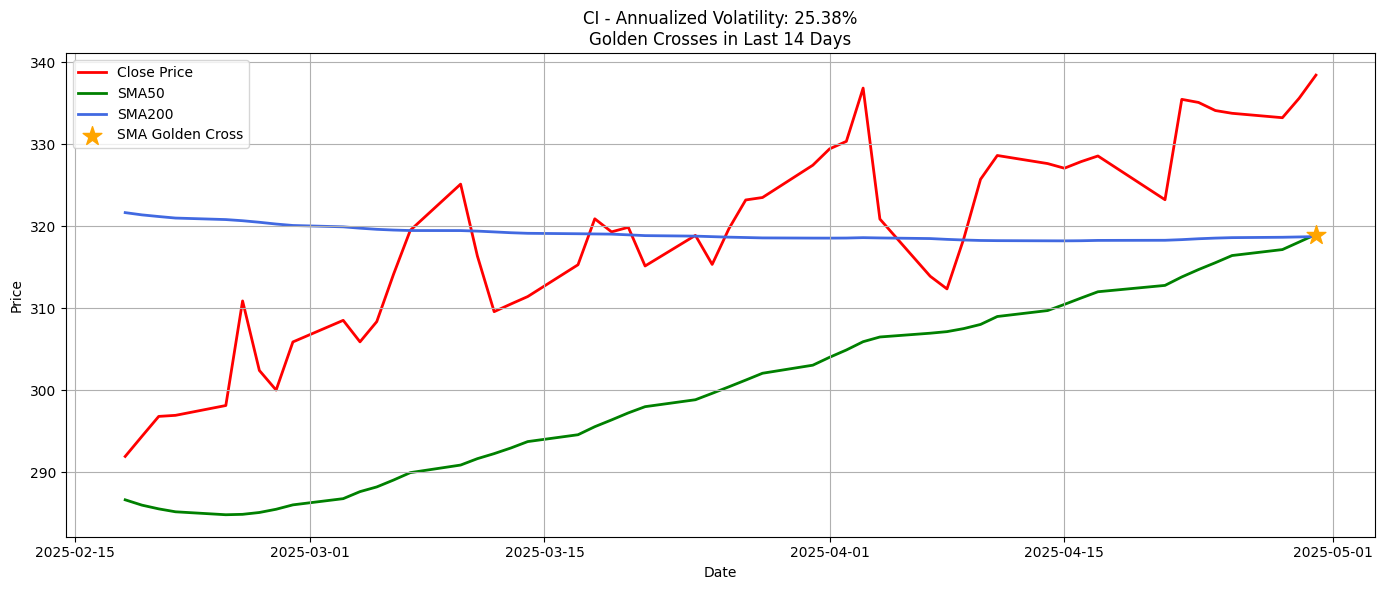

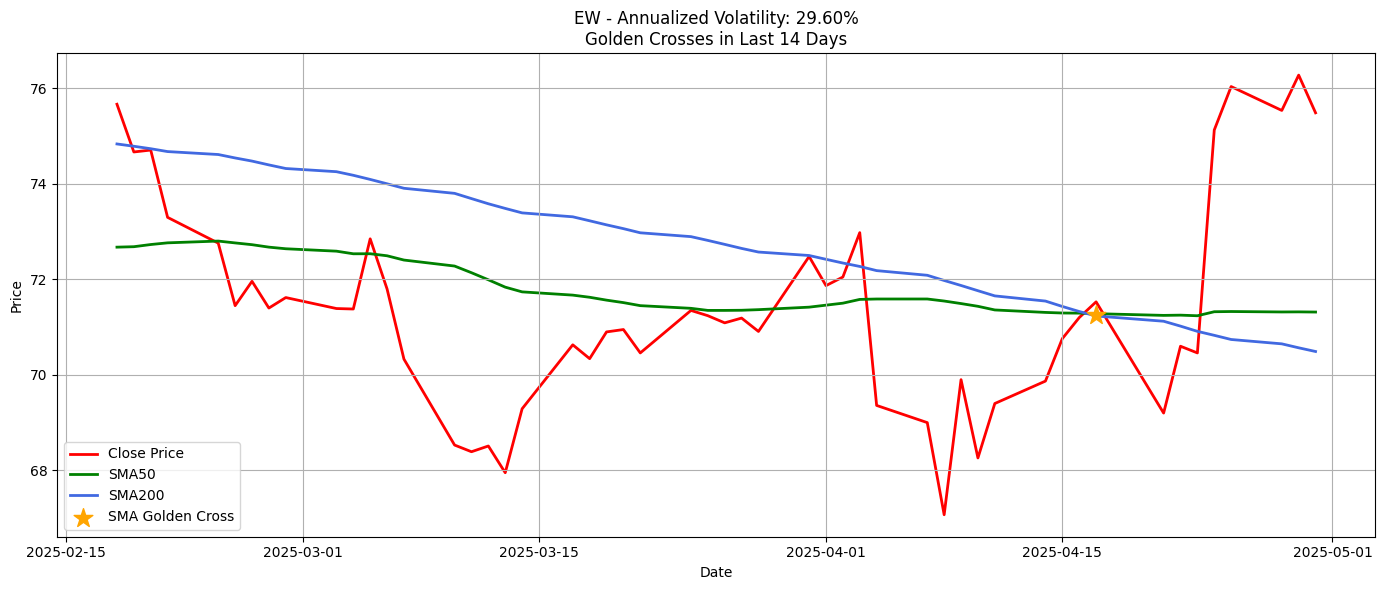

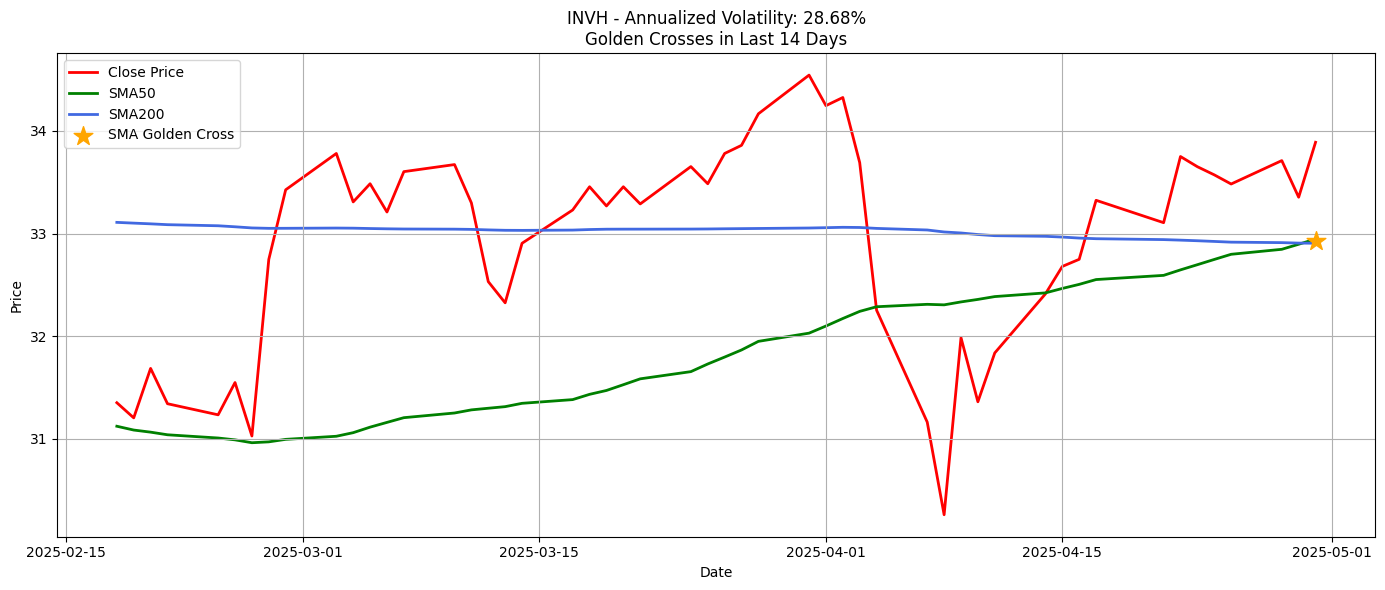

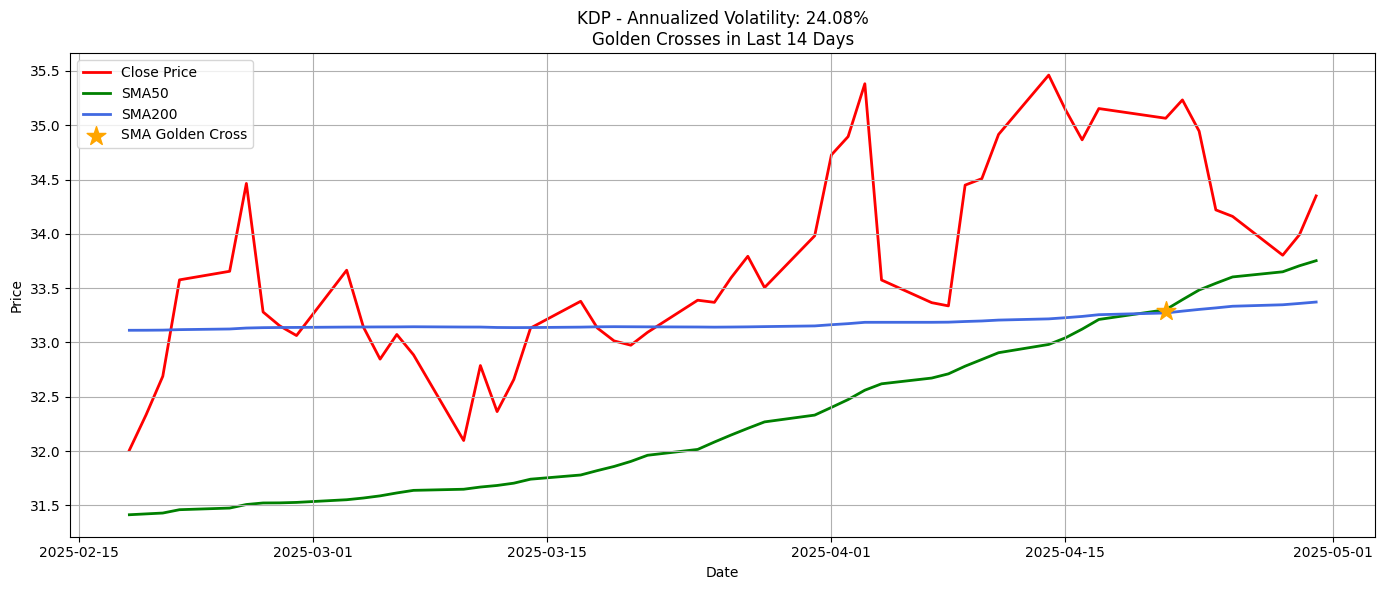

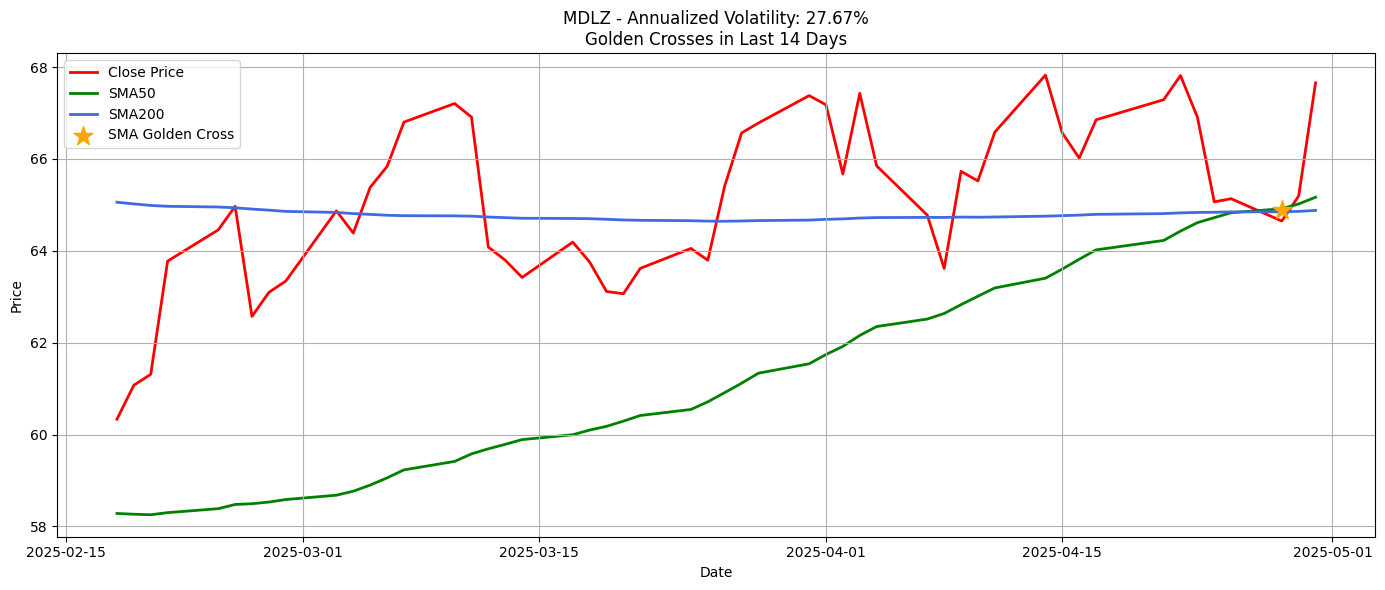

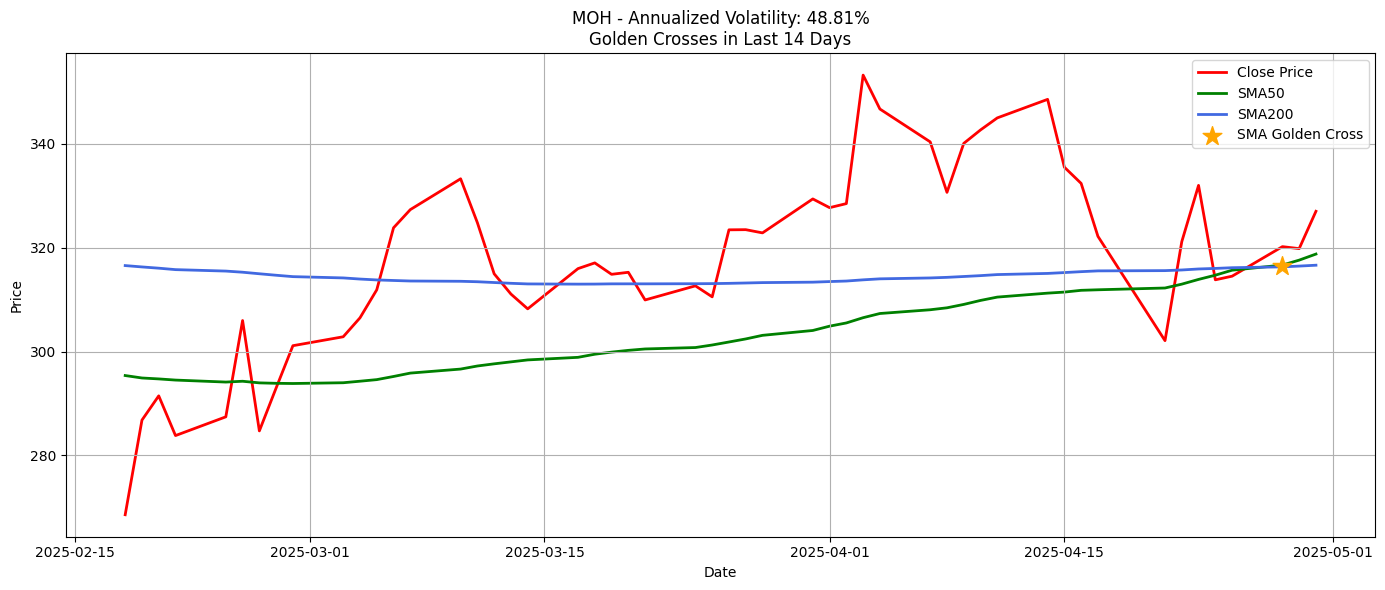

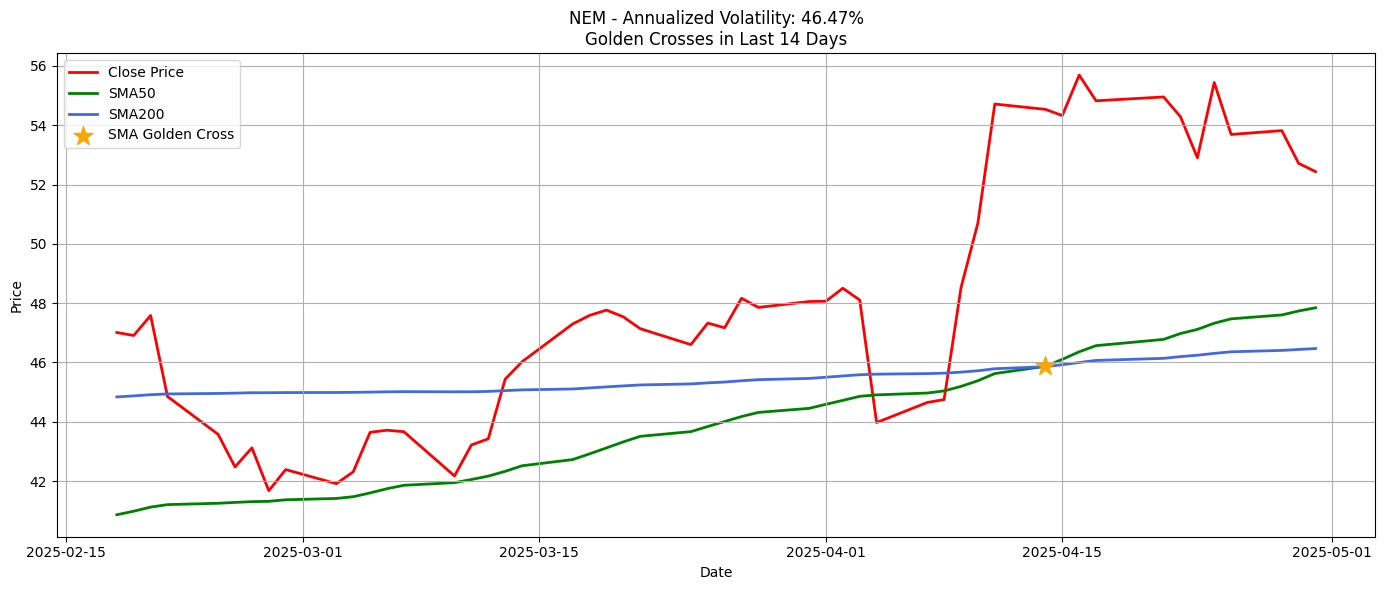

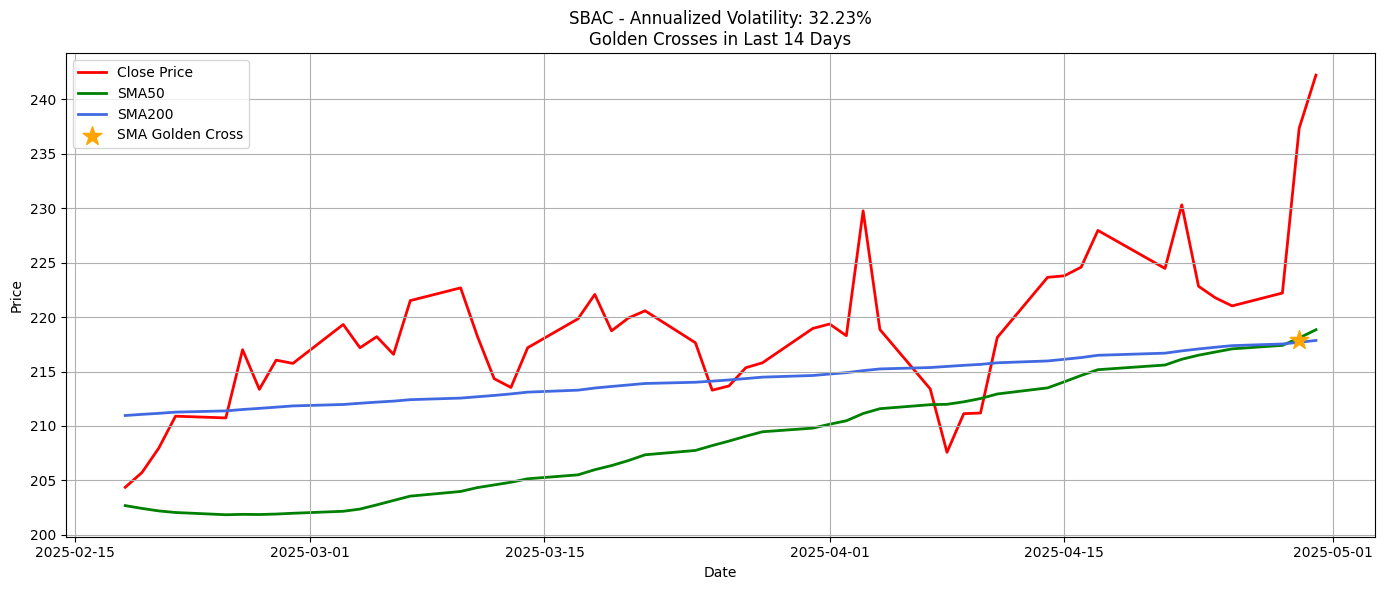

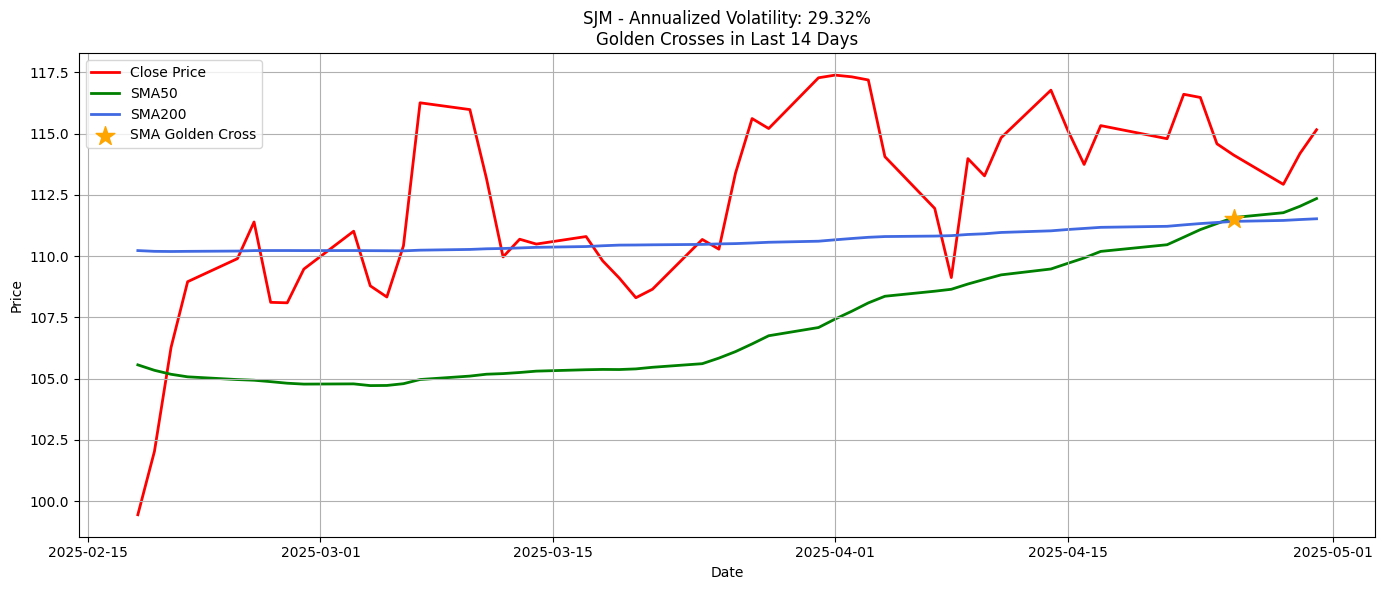

In [15]:
def plot_top10_golden_crosses(df_close, df_golden, window=14):
    """
    Plot the top 10 tickers (alphabetically) that had Golden Crosses in the last `window` days.
    Each plot includes closing price, SMA50, SMA200, volatility, and stars marking SMA crossovers.
    """

    top10_tickers = sorted(df_golden['Ticker'].unique())[:10]

    for ticker in top10_tickers:
        if ticker not in df_close.columns:
            continue

        df = pd.DataFrame()
        df['Close'] = df_close[ticker]
        df['SMA50'] = df['Close'].rolling(window=50).mean()
        df['SMA200'] = df['Close'].rolling(window=200).mean()
        df.dropna(inplace=True)

        if df.empty:
            continue

        daily_returns = df['Close'].pct_change().dropna()
        if len(daily_returns) < 2:
            continue
        volatility = daily_returns.std() * np.sqrt(252)
        vol_pct = volatility * 100

        golden_dates = df_golden[df_golden['Ticker'] == ticker]['Date']

        plt.figure(figsize=(14, 6))
        plt.plot(df.index, df['Close'], label='Close Price', color='red', linewidth=2, zorder=1)
        plt.plot(df.index, df['SMA50'], label='SMA50', color='green', linewidth=2, zorder=1)
        plt.plot(df.index, df['SMA200'], label='SMA200', color='royalblue', linewidth=2, zorder=1)

        # Mark Golden Cross (triangle up) at closing price
        for d in golden_dates:
            if d in df.index:
                plt.scatter(d, df.loc[d, 'Close'], marker='^', color='green', s=120, label='Golden Cross', zorder= 4)

        # Detect Golden Cross points (SMA50 crossing above SMA200)
        cross_up = (df['SMA50'] > df['SMA200']) & (df['SMA50'].shift(1) <= df['SMA200'].shift(1))

        # Draw star marker at the SMA crossover point (average of SMA50 and SMA200)
        for date in df.index[cross_up]:
            avg_price = (df.loc[date, 'SMA50'] + df.loc[date, 'SMA200']) / 2
            plt.scatter(date, avg_price, marker='*', color='orange', s=200, label='SMA Golden Cross', zorder=5)

        plt.title(f"{ticker} - Annualized Volatility: {vol_pct:.2f}%\nGolden Crosses in Last {window} Days")
        plt.xlabel('Date')
        plt.ylabel('Price')
        plt.grid(True)

        # Avoid duplicate legend entries
        handles, labels = plt.gca().get_legend_handles_labels()
        by_label = dict(zip(labels, handles))
        plt.legend(by_label.values(), by_label.keys())

        plt.tight_layout()
        plt.show()

# Usage example:
plot_top10_golden_crosses(df_close, df_golden_cross_14d, window=14)

### Plot top 10 stocks that had Death Crosses in the last 14 days

You should have 10 plots (use a for loop) for every stock in the top 10 (in alphabetical order)
For each plot, put the volatility of the stock in the title of the plot

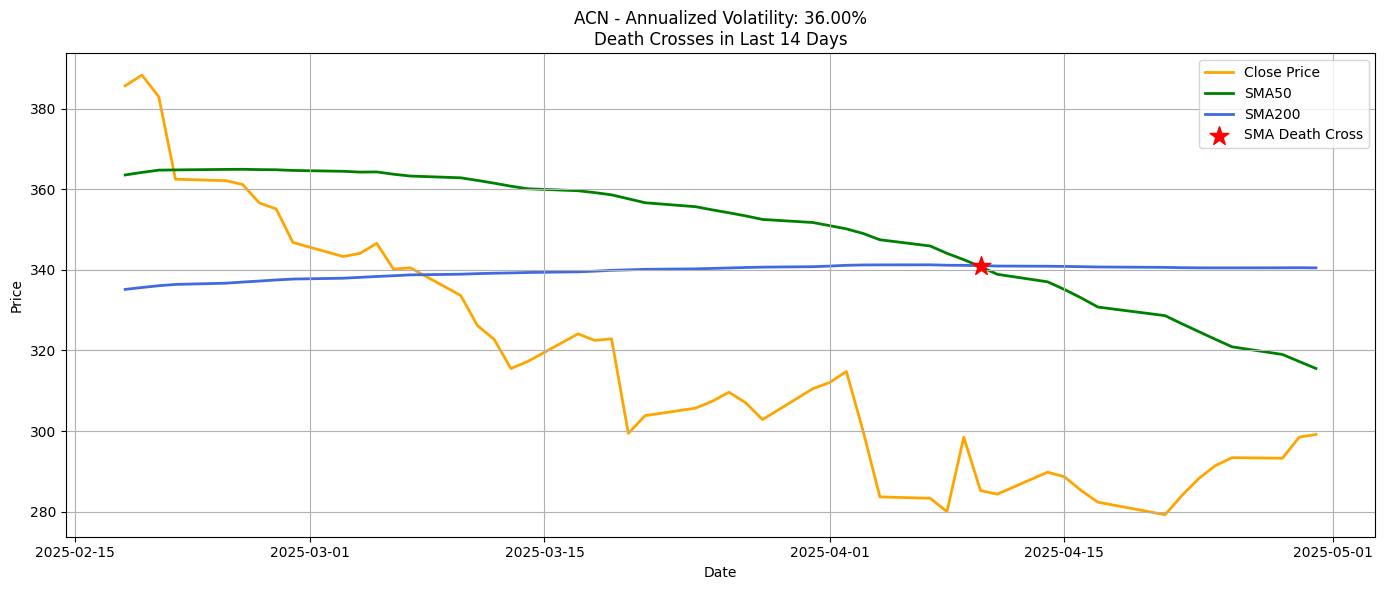

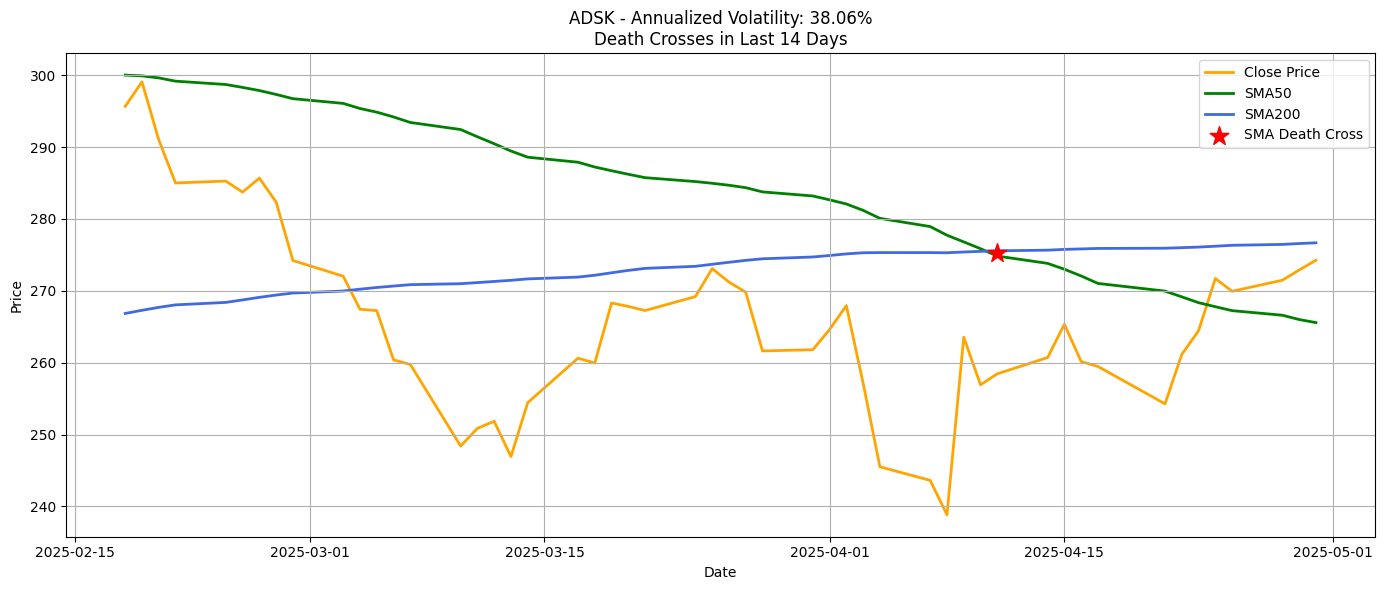

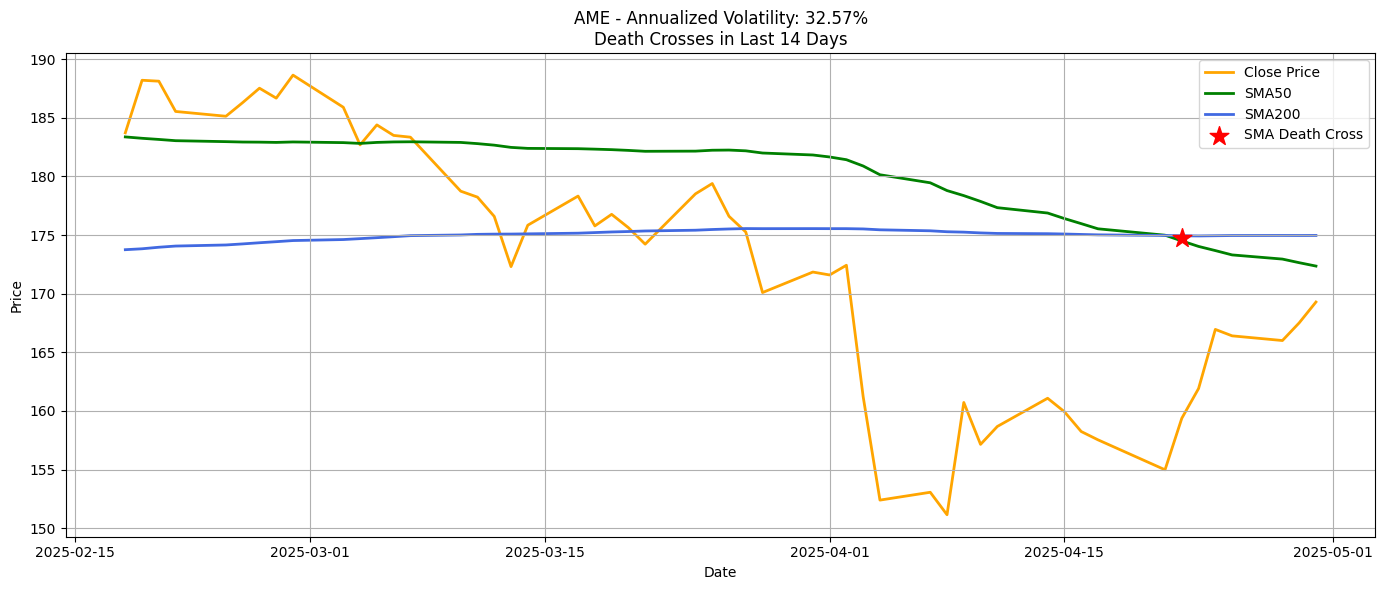

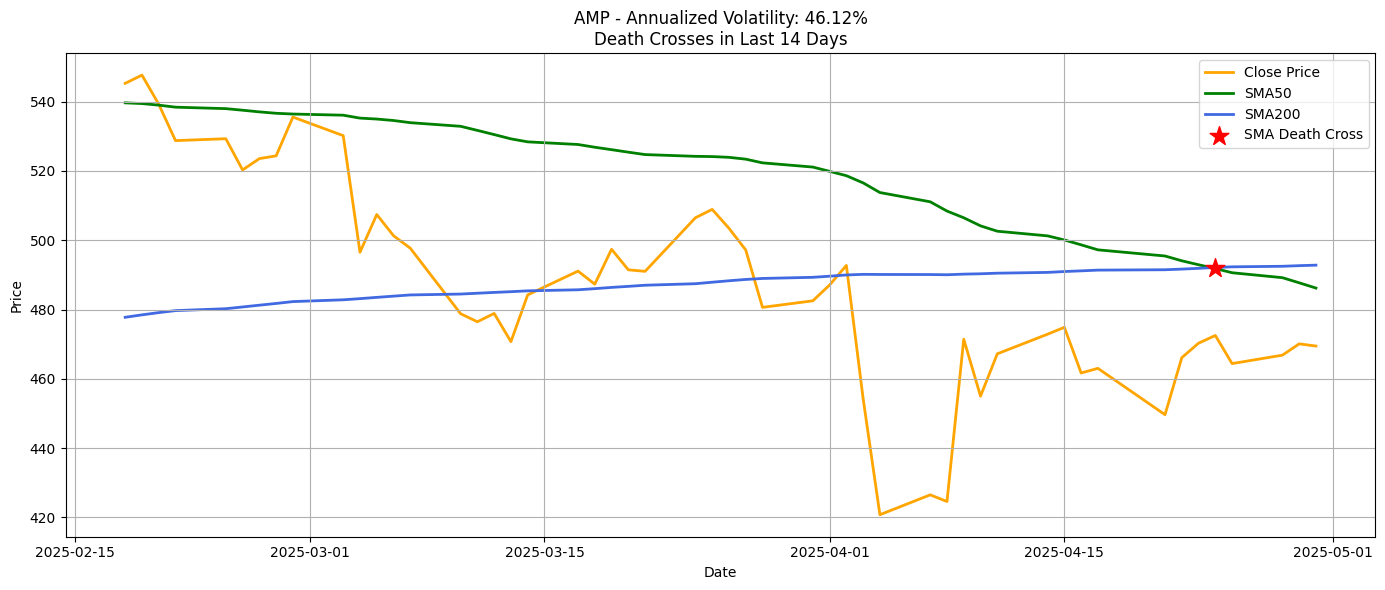

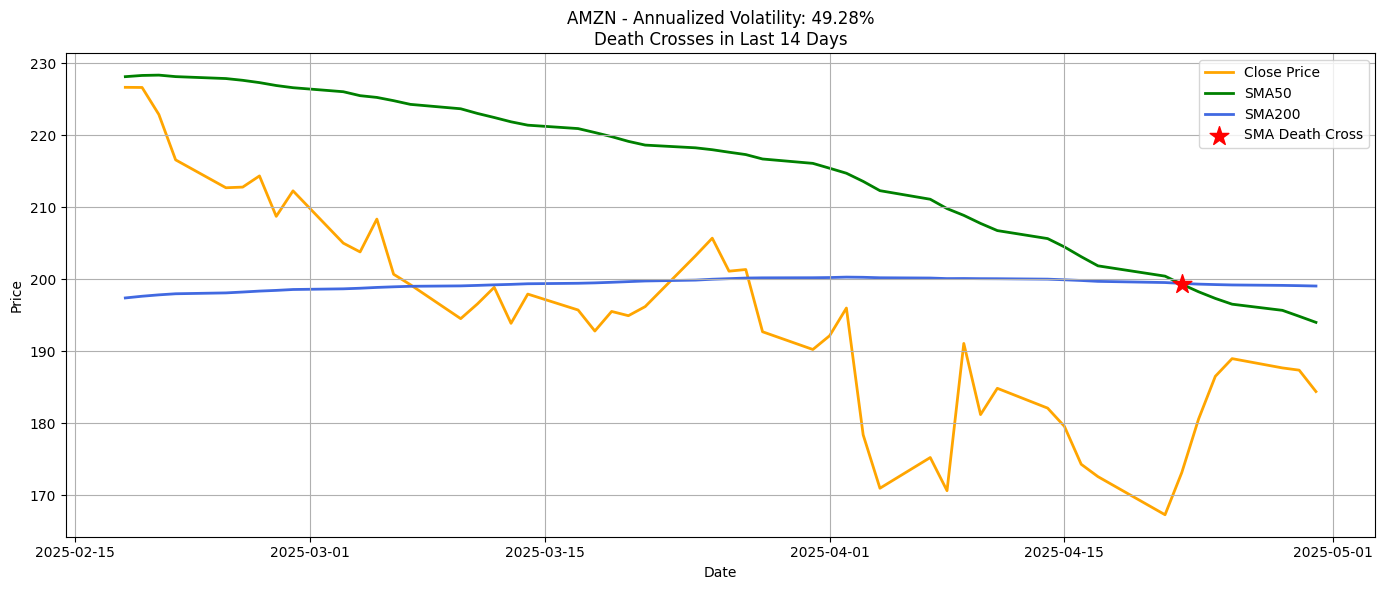

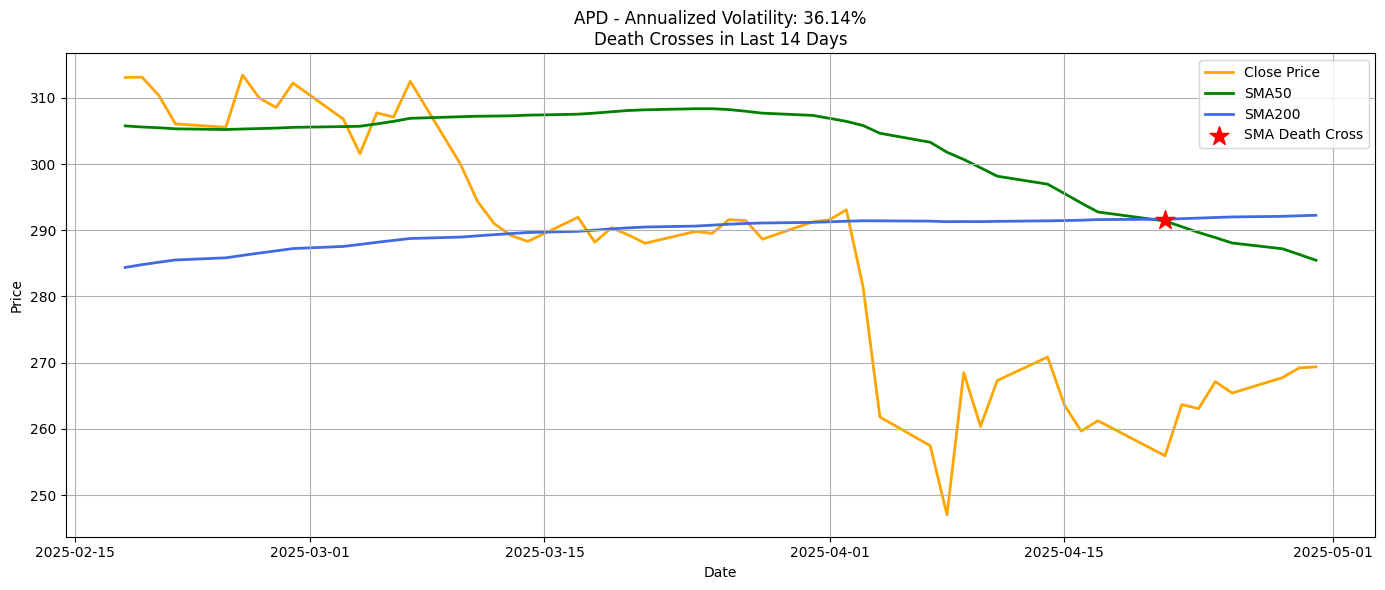

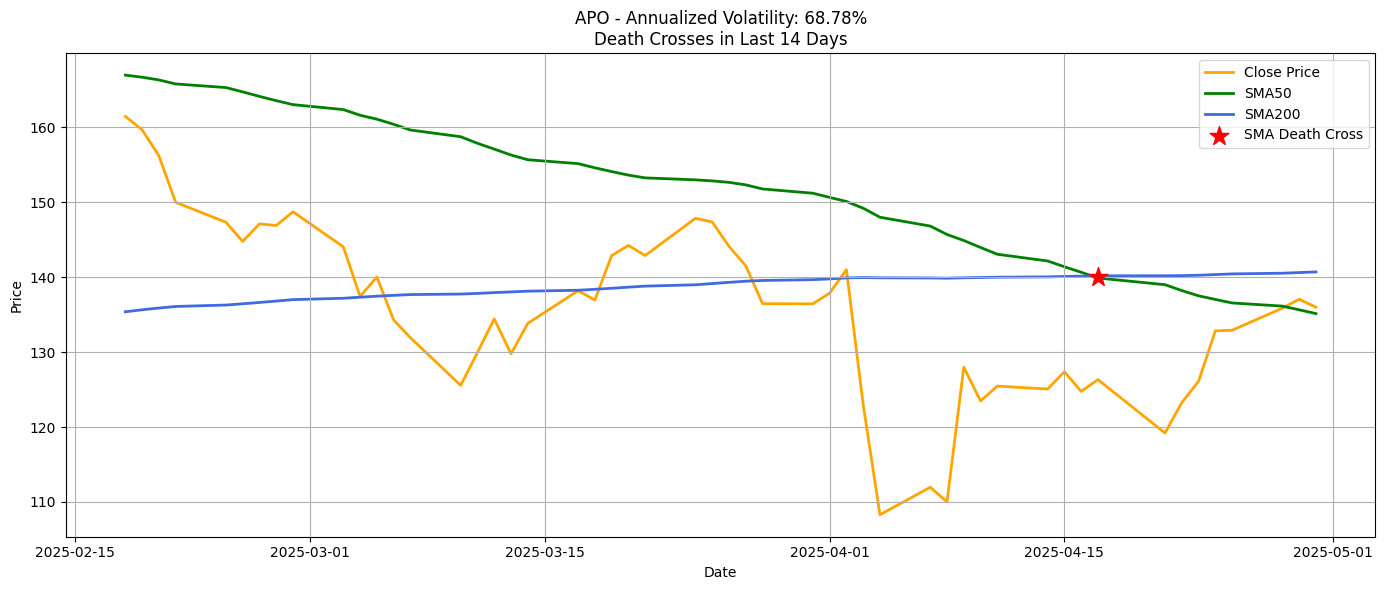

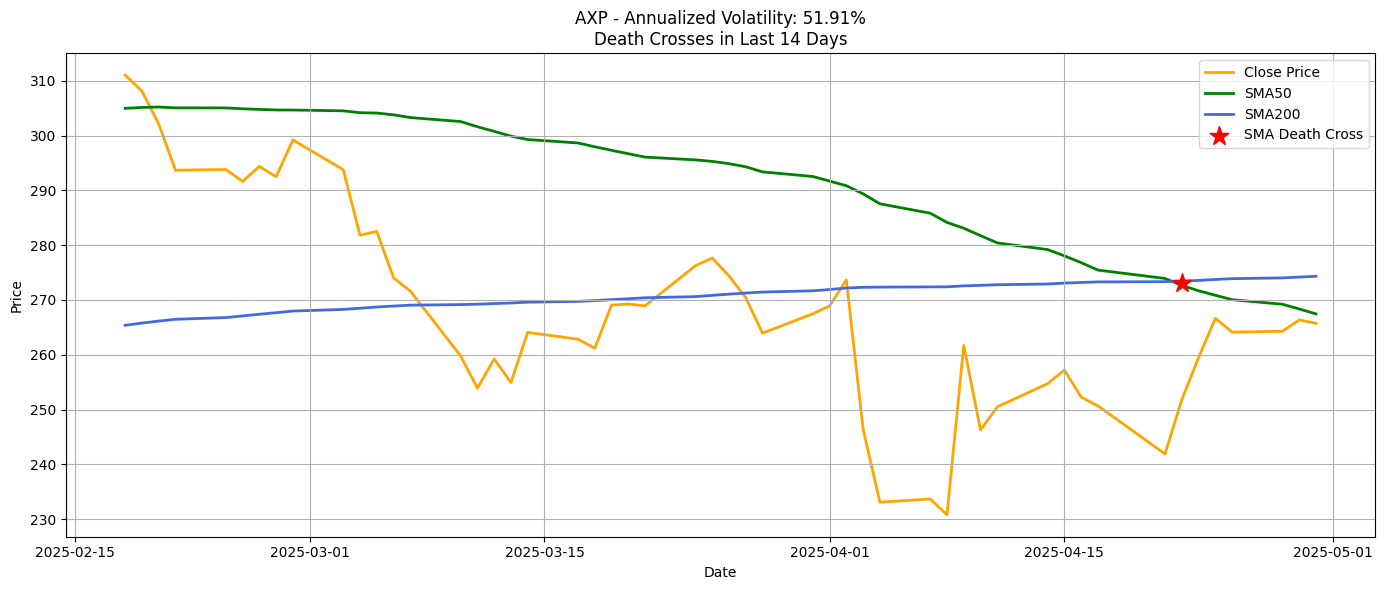

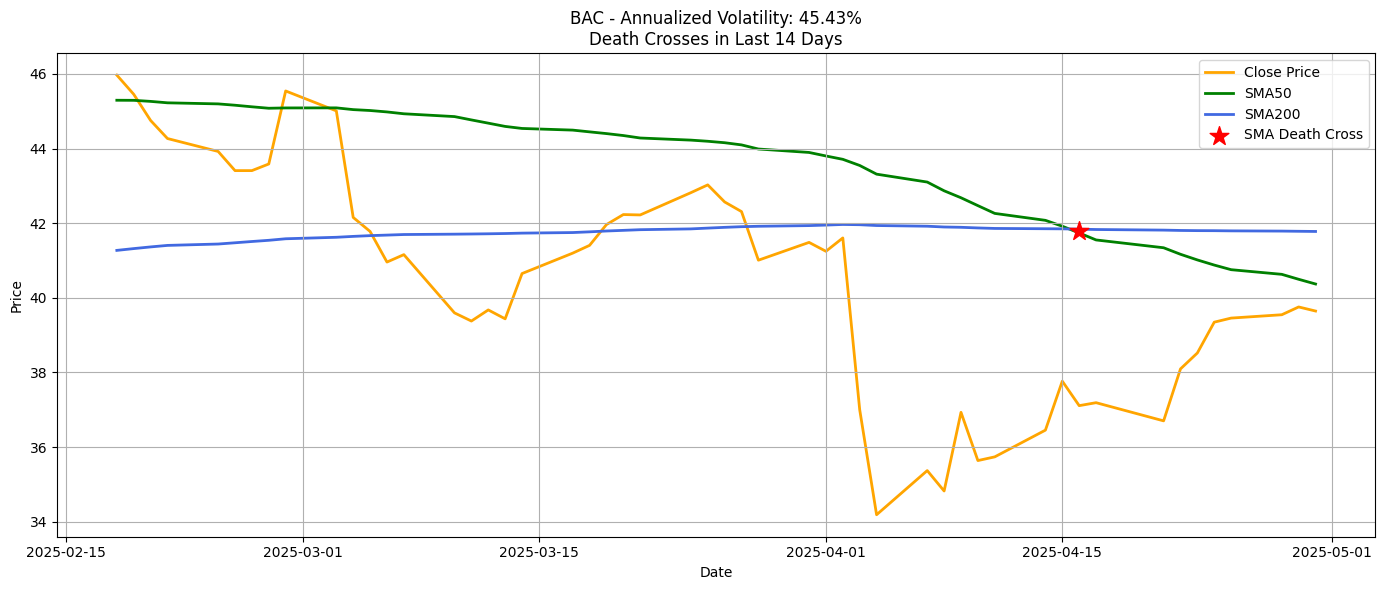

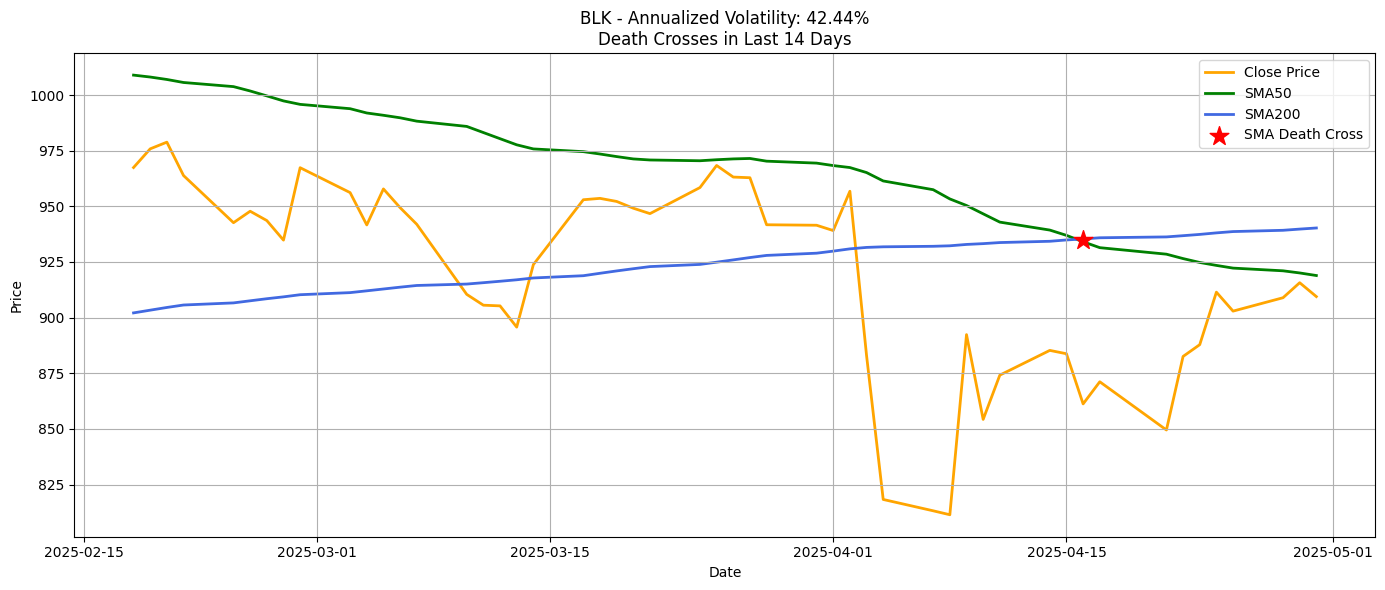

In [16]:
# CODE HERE
# Visualize the results here
def plot_top10_death_crosses(df_close, df_death, window=14):
    """
    Plot the top 10 tickers (alphabetically) that had Death Crosses in the last `window` days.
    Each plot includes closing price, SMA50, SMA200, volatility,
    and stars marking SMA crossovers (Death Cross).
    """

    top10_tickers = sorted(df_death['Ticker'].unique())[:10]

    for ticker in top10_tickers:
        if ticker not in df_close.columns:
            continue

        df = pd.DataFrame()
        df['Close'] = df_close[ticker]
        df['SMA50'] = df['Close'].rolling(window=50).mean()
        df['SMA200'] = df['Close'].rolling(window=200).mean()
        df.dropna(inplace=True)

        if df.empty:
            continue

        daily_returns = df['Close'].pct_change().dropna()
        if len(daily_returns) < 2:
            continue
        volatility = daily_returns.std() * np.sqrt(252)
        vol_pct = volatility * 100

        death_dates = df_death[df_death['Ticker'] == ticker]['Date']

        plt.figure(figsize=(14, 6))
        plt.plot(df.index, df['Close'], label='Close Price', color='orange', linewidth=2, zorder=1)
        plt.plot(df.index, df['SMA50'], label='SMA50', color='green', linewidth=2, zorder=1)
        plt.plot(df.index, df['SMA200'], label='SMA200', color='royalblue', linewidth=2, zorder=1)

        # Mark Death Cross (down triangle) at closing price
        for d in death_dates:
            if d in df.index:
                plt.scatter(d, df.loc[d, 'Close'], marker='v', color='red', s=120, label='Death Cross', zorder=4)

        # Detect Death Cross points (SMA50 crossing below SMA200)
        cross_down = (df['SMA50'] < df['SMA200']) & (df['SMA50'].shift(1) >= df['SMA200'].shift(1))

        # Draw star marker at the SMA crossover point (average of SMA50 and SMA200)
        for date in df.index[cross_down]:
            avg_price = (df.loc[date, 'SMA50'] + df.loc[date, 'SMA200']) / 2
            plt.scatter(date, avg_price, marker='*', color='red', s=200, label='SMA Death Cross', zorder= 5)

        plt.title(f"{ticker} - Annualized Volatility: {vol_pct:.2f}%\nDeath Crosses in Last {window} Days")
        plt.xlabel('Date')
        plt.ylabel('Price')
        plt.grid(True)

        # Avoid duplicate legend entries
        handles, labels = plt.gca().get_legend_handles_labels()
        by_label = dict(zip(labels, handles))
        plt.legend(by_label.values(), by_label.keys())

        plt.tight_layout()
        plt.show()

# Usage:
plot_top10_death_crosses(df_close, df_death_cross_14d, window=14)

## Question section

### Understanding concepts

#### What is a Golden Cross and what does it typically signal to investors?

A Golden Cross is a bullish signal in trading. It happens when a short-term moving average (like the 50-day) crosses above a long-term moving average (like the 200-day).

Why It Matters
- It often signals the start of an uptrend.
- Traders see it as a sign to buy, expecting prices to rise.
- It shows growing market confidence.


#### What is a Death Cross and how might market participants react to it?

A Death Cross is a bearish technical signal that occurs when a short-term moving average (like the 50-day) crosses below a long-term moving average (like the 200-day).

What Does It Mean?
- It often signals a potential downtrend or market weakness.
- Traders may take it as a sign to sell, reduce exposure, or avoid entering long positions.
- It suggests that recent price momentum is slowing or reversing.



#### Why might moving averages (MA50, MA200) be used as indicators in technical analysis?

Moving averages like the MA50 (50-day) and MA200 (200-day) are popular tools in technical analysis because they help traders and investors make sense of price trends over time.

MA50 reflects the short-to-mid-term trend (roughly 2–3 months). MA200 shows the long-term trend (almost a year of trading days). Together, they offer a balanced view short-term behavior vs. big-picture direction.



#### Why are the last 14 days used to check for crosses? What are the implications of this choice?

**Timely Detection:**

The goal is to catch a moving average crossover soon after it happens, but not too early, to avoid false signals. 14 days gives a reasonable window to spot recent changes while confirming the crossover is sustained, not just a one-day fluke.

**Avoiding Whipsaws:**

Very short windows (like 1–3 days) might catch noise. A 14-day lookback helps confirm that the crossover is real and holding, not just a temporary dip or spike.

**Balance Between Reactivity and Reliability:**

It’s short enough to react before the trend is too mature, but long enough to avoid jumping on weak signals.


#### How does volatility (e.g., measured using percentage change standard deviation) help contextualize the price movement around crosses?

Volatility especially when measured using the standard deviation of percentage price changes is a key context when interpreting moving average crosses like the Golden Cross or Death Cross.

However, volatility measures how wildly or calmly a stock’s price moves over time. One common way to measure it is standard deviation of daily percentage changes.

Some volatility Helps Interpret Moving Average Crosses are:
- Signal Confidence
- Avoiding False Breakouts
- Risk Management
- Trend Strength Insight


### Backtesting and evaluation

#### How would you measure whether Golden Crosses actually lead to profitable trades?

To measure whether Golden Crosses actually lead to profitable trades, you'd approach it like a backtesting problem evaluating how a Golden Cross strategy would have performed on historical data.

Some strategy:
- Buy: When the 50-day moving average crosses above the 200-day moving average.
- Sell: When the 50-day MA later crosses below the 200-day (Death Cross), or after a fixed time (e.g. 3 or 6 months).

#### What are the risks of using only technical indicators like moving averages without incorporating fundamentals?

Relying only on technical indicators can leave you vulnerable to false signals, unexpected events, and poor long-term decisions. Combining technicals with fundamental analysis gives a clearer, more complete picture of risk and opportunity.

#### How would you improve this strategy to reduce false signals (e.g., a Golden Cross that doesn’t lead to a price increase)?

To reduce false signals and improve decision-making, integrate technical indicators with volume and volatility analysis, and support them with fundamental data such as earnings or valuation metrics. Strengthen trend confirmation through tools like RSI, MACD, or moving average alignment. Finally, implement consistent risk management practices such as stop-losses, position sizing, and clear exit rules—to manage downside risk and preserve capital.

### AI Integration


#### Could sentiment from news (future project part) help validate or invalidate these technical signals?

News sentiment can definitely enhance the reliability of technical signals like the Golden Cross. A bullish crossover may look promising on a chart, but if recent headlines are negative such as poor earnings, lawsuits, or industry-wide issues it could suggest the signal is misleading.

Conversely, if a Golden Cross coincides with positive news, that sentiment can reinforce the signal, indicating the momentum may be real rather than just a temporary fluctuation.

Sentiment is especially valuable when signals are uncertain. For instance, if the technicals say buy but sentiment is neutral or negative, it may be wise to hold off or reduce risk. In this way, sentiment acts as a second layer of confirmation or caution beyond the chart.

In more advanced strategies, you could even integrate sentiment directly only acting on Golden Crosses when the past few days’ sentiment is positive. This kind of filter can help reduce false signals and improve trade quality.

In short, while technical indicators reflect what is happening in price action, sentiment provides insight into why it might be happening or whether it will last. Combining both gives a more complete, smarter trading picture.

### Critical thinking

#### From a trading perspective, is this strategy actionable on its own?

From a trading perspective, the Golden Cross strategy signals a potential shift in bullish momentum occurring when the 50-day moving average crosses above the 200-day moving average. This crossover suggests that recent price trends are strengthening, often interpreted as the beginning of a longer term uptrend.

However, because both moving averages are lagging indicators, the signal often appears after a significant portion of the move has already occurred. In volatile or sideways markets, it can produce false positives where the crossover is followed by a quick reversal.

**To improve its reliability, traders commonly combine the Golden Cross with other technical indicators:**

- The Relative Strength Index (RSI) helps assess whether the stock is overbought or oversold at the time of the signal.

- The MACD (Moving Average Convergence Divergence) can confirm whether bullish momentum is building.

A surge in trading volume during the crossover adds further conviction to the signal.

On its own, the Golden Cross has limited predictive power. Its effectiveness improves significantly when it's aligned with supporting indicators and the broader market context.

#### Based on the volatility observed post-Golden Cross, do these crosses consistently predict upward movement?

The Golden Cross, where the 50-day moving average crosses above the 200-day moving average, is commonly interpreted as a bullish signal. However, an analysis of three stocks ADSK, AME, and AMP shows that this pattern did not consistently lead to sustained upward trends.

ADSK: In late 2024, ADSK formed a Golden Cross and experienced a brief price increase. However, by early 2025, the stock declined sharply. Despite moderate volatility, the bullish momentum failed to continue, signaling a false positive.

AME: AME also presented a Golden Cross in late 2024. While the price initially rose, it soon entered a steady decline. Even with relatively low volatility, the pattern did not result in a lasting uptrend, suggesting that low volatility alone did not validate the signal.

AMP: AMP experienced a Golden Cross just before Q1 2025. Like the others, it saw a brief rally followed by a sharp decline. With the highest volatility among the three, the signal lacked staying power, highlighting the impact of unstable market conditions.

Conclusion:

While the Golden Cross remains a popular technical indicator, in these three cases it failed to predict sustained bullish movements. Each stock showed an initial upward reaction, followed by a reversal—often under conditions of elevated or moderate volatility.

This analysis suggests that the Golden Cross should not be used in isolation. Instead, it should be combined with additional tools, such as sentiment analysis, volume confirmation, and broader market context, to improve decision-making and reduce the risk of false signals.


#### If you had to present this analysis to a portfolio manager, what conclusions would you emphasize? What caveats would you include?

When discussing this analysis with a portfolio manager, I would start by acknowledging that the Golden Cross is widely regarded as a bullish indicator. However, in the examples reviewed (ADSK, AME, AMP), it did not consistently lead to sustained upward trends. Each stock experienced short-term price gains followed by declines, often with elevated volatility, suggesting market uncertainty following the signal.

It’s also important to point out some limitations. First, the analysis covers only three stocks, so the findings may not apply broadly. Second, technical indicators like the Golden Cross are inherently lagging and may be slow to respond in volatile or rapidly changing markets. Finally, external events and company-specific news likely influenced price action, complicating the isolation of the crossover’s true effect.

In conclusion, I would recommend considering the Golden Cross as one component of a wider analytical framework rather than relying on it solely for investment decisions.

Conclusions in 2 bullet points:

- The Golden Cross did not consistently lead to lasting upward trends in ADSK, AME, and AMP. While initial price gains were observed, they were quickly followed by declines, indicating limited predictive strength.
- In these cases, the Golden Cross signaled only short-term rallies rather than sustained growth. The subsequent high volatility reflects uncertainty and a lack of momentum after the crossover.


Caveats in 2 or 3 bullet points:

- This analysis is limited to three stocks and may not reflect the behavior of the broader market. External factors like economic news or company announcements could have influenced price movements independent of technical signals.
- Moving average crossovers are inherently lagging indicators that may respond too slowly in volatile or rapidly changing markets. Therefore, relying solely on this signal carries risks of delayed or false signals.